In [1]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import random
import time
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# This selects the compute device: use GPU ('cuda') if available,
# otherwise fall back to CPU. This ensures compatibility on all systems.
# device = torch.device("cuda") if torch.cuda_is_available() else torch.device("cpu")

# Set device to MPS for macbook.
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

Using device: MPS (Apple Silicon GPU)


In [3]:
def set_seed(seed=42):
    """
    Set the random seed for reproducibility.
    This ensures that NumPy and Pytorch generate the same results each time,
    which is important for debugging and consistent experiments.
    """
    torch.manual_seed(seed)  # Set Pytorch's random seed
    np.random.seed(seed)     # Set NumPy's random seed
    
    if device.type == 'cuda':
        torch.cuda.manual_seed(seed)
        # Make CUDA (GPU) operations deterministic to ensure repeatable results
        # This may slightly reduce performance but improves reproducibility
        torch.backends.cudnn.deterministic = True

# Apply the seed value (commonly used default)        
set_seed(42)

In [4]:
# Define a set of data augmentations for the train dataset
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(), # Converts PIL image to Pytorch Tensor
    transforms.Normalize((0.5,), (0.5,))
])

# Validation transformations -No augmentation beyond basic inputs setup
val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(), # Converts PIL image to Pytorch Tensor
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
# Set data paths
# CNN trained, validated, and tested on original 109K from https://data.mendeley.com/datasets/rscbjbr9sj/3
# base_path = '/Users/port/Downloads/Dataset - train+val+test'
# Subset of dataset submitted with notebook
base_path = '/Users/port/Downloads/Dataset_Mini - train+val+test'
train_path = os.path.join(base_path, 'train')
val_path   = os.path.join(base_path, 'val')
test_path  = os.path.join(base_path, 'test')

In [6]:
# Load the dataset and apply transformations
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=val_path, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(root=test_path, transform=val_test_transforms)

# Create dataloaders
# batch_size=64 loads 64 images at a time
# shuffle=True randomizes the order
# num_workers=0 to prevent errors with macbook processing, set to 5 for other devices
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)

#shuffle=False by default
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

### EDA

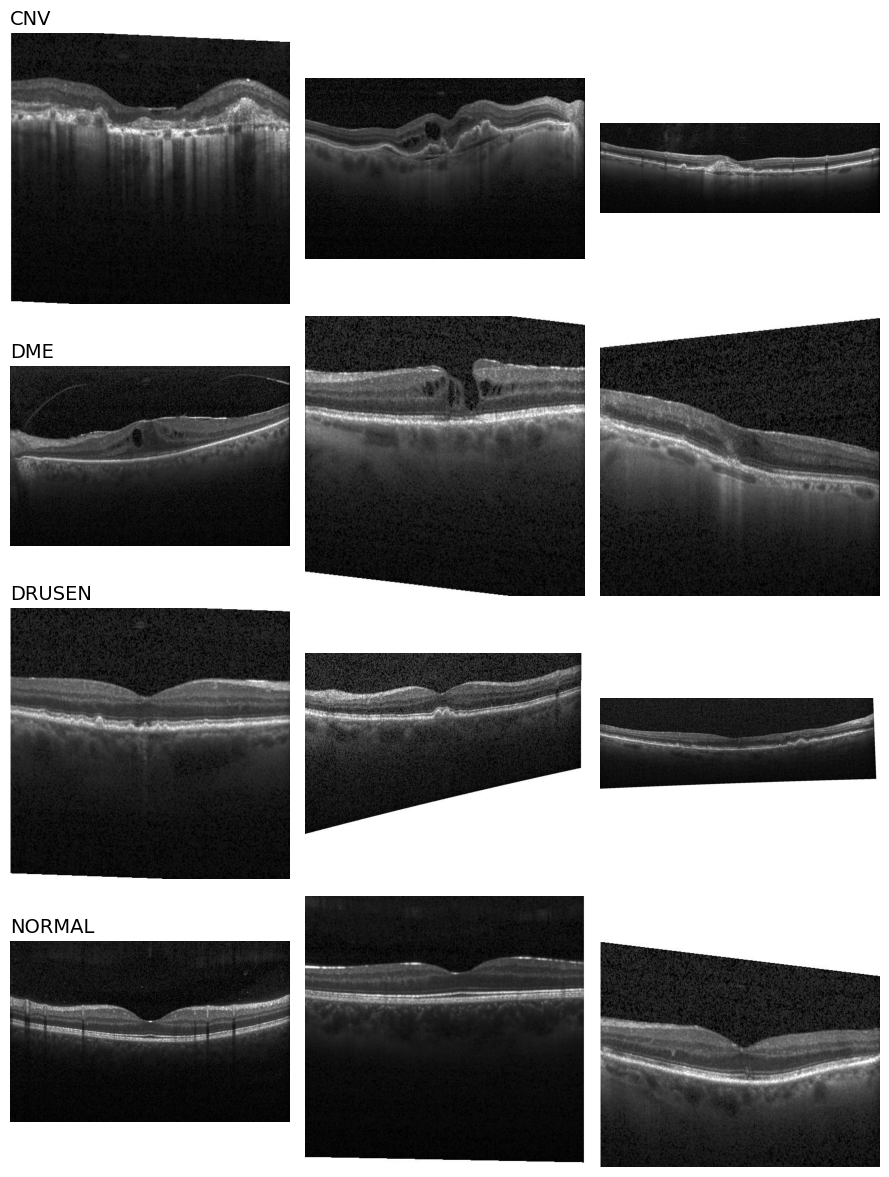

In [7]:
# Visualization of the dataset - Sample images from the dataset
def show_samples(dataset, samples_per_class=3):
    classes = dataset.classes
    fig, axes = plt.subplots(len(classes), samples_per_class,
                             figsize=(samples_per_class*3, len(classes)*3))

    for i, class_name in enumerate(classes):
        class_indices = [idx for idx, (_, label) in enumerate(dataset.samples)
                         if label == i]

        selected = random.sample(class_indices, samples_per_class)

        for j, idx in enumerate(selected):
            img_path, _ = dataset.samples[idx]
            img = Image.open(img_path).convert("L")

            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].axis("off")

            if j == 0:
                axes[i, j].set_title(class_name, fontsize=14, loc='left')

    plt.tight_layout()
    plt.show()

show_samples(train_dataset, samples_per_class=3)

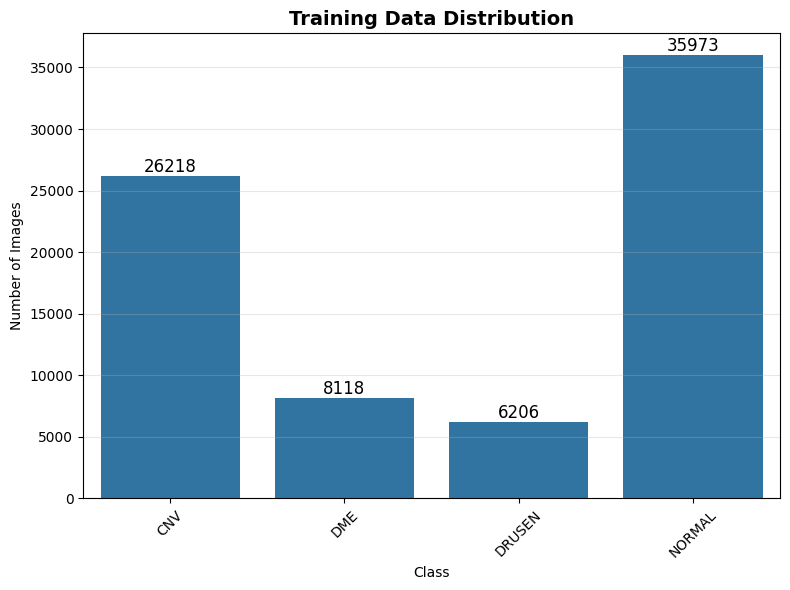

In [29]:
# Visualization of the dataset - Class Distribution Plot
# Count images per class
class_counts = {}

for _, label in train_dataset.samples:
    class_name = train_dataset.classes[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

df_counts = pd.DataFrame.from_dict(class_counts, orient='index',
                                   columns=['Count']).reset_index()
df_counts.columns = ['Class', 'Count']

plt.figure(figsize=(8,6))
ax = sns.barplot(data=df_counts, x='Class', y='Count')

# Add value labels on bars
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12)

plt.title("Training Data Distribution", fontsize=14, weight='bold')
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()


plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Show the classes to confirm dataset is loaded
class_names = train_dataset.classes
print(f"Classes: {class_names}")

Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


## Train Models

In [10]:
# Define CNN model for 4-class OCT Classification
C = 1 # C is the number of channels.For greyscale images set C=1
filters = 32 # We chose 32 to detect subtle textural changes in fluid pockets
classes = 4 # The number of classes for classification (CNV, DME, Drusen, Normal)
img_size = 128 # Image dimensions

# Two MaxPool2d(2) layers reduce the 128x128 input to 32x32
final_dim = img_size // 4
# The final Conv block doubles the initial filter count to 64 (2 * filters)
# Flatten size = (final Channels) * (Final Height) * (Final Width)
flattened_size = (2 * filters) * final_dim * final_dim

model_cnn = nn.Sequential(
    #First Convolution Block: Initial feature extraction
    nn.Conv2d(in_channels=C, out_channels=filters, kernel_size=3, stride=1, padding=1),#32 features 3x3 kernel
    nn.BatchNorm2d(num_features=filters),    # Normalize channel-wise activations in 4D input
    nn.ReLU(inplace=True),    # Apply non-linear activation (Rectified Linear Unit)
    nn.Conv2d(in_channels=filters, out_channels=filters, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(num_features=filters),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2),    # Reduces spatial dimension in half

    # Second Convolution Block: Feature refinement (No downsampling)
    nn.Conv2d(in_channels=filters, out_channels=filters, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(num_features=filters),
    nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=filters, out_channels=filters, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(num_features=filters),
    nn.ReLU(inplace=True),

    # Third Convolution Block: Prepares features for classifcation
    nn.Conv2d(in_channels=filters, out_channels=2*filters, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(num_features=2*filters),
    nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=2*filters, out_channels=2*filters, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(num_features=2*filters),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2),

    
    nn.Flatten(start_dim=1),    # Flatten the output
    nn.Dropout(p=0.4),    # Regularization to prevent overfitting
    nn.Linear(in_features=flattened_size, out_features=classes)    #Final linear layer transforms into 4 target classes
).to(device)

In [11]:
loss_func = nn.CrossEntropyLoss()
def train_simple_network(model, loss_func, train_loader, test_loader, score_funcs, device, epochs=20):
    # Adam optimizer with .001 lr
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # Define the loss function
    history = {'epoch': [], 'Accuracy': [], 'test Accuracy': [], 'Train Loss': [], 'Test Loss': [], 'Epoch Time (sec)': []}

    for epoch in range(epochs):
        # Record epoch time
        epoch_start = time.time()
        # training
        model.train()
        total_train_loss = 0
        train_preds, train_labels = [], []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # test/validation
        model.eval()
        total_test_loss = 0
        test_preds, test_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)

                loss = loss_func(outputs, labels)
                total_test_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                test_preds.extend(preds.cpu().numpy())
                test_labels.extend(labels.cpu().numpy())

        # End epoch timer
        if device.type == "cuda":
            torch.cuda.synchronize()  # ensures GPU ops finish before timing
        epoch_time = time.time() - epoch_start

        # Save metrics to history
        history['epoch'].append(epoch + 1)
        history['Train Loss'].append(total_train_loss / len(train_loader))
        history['Test Loss'].append(total_test_loss / len(test_loader))
        history['Accuracy'].append(score_funcs['Accuracy'](train_labels, train_preds))
        history['test Accuracy'].append(score_funcs['Accuracy'](test_labels, test_preds))
        history['Epoch Time (sec)'].append(epoch_time)

        print(f"Epoch {epoch+1}/{epochs}:, Train Acc: {history['Accuracy'][-1]:.4f}, Test Acc: {history['test Accuracy'][-1]:.4f}, Test Loss: {history['Test Loss'][-1]:.4f}", f"Time: {epoch_time:.1f}s")


    return history

In [12]:
# Train the CNN
cnn_results = train_simple_network(
    model_cnn,
    loss_func,
    train_loader,
    test_loader=val_loader,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    epochs=20
)
# Move model to eval mode
model_cnn.eval()
test_preds, test_labels = [], []
#Disable gradient computation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(test_labels, test_preds)
print(f"\n Final Test Accuracy: {final_test_acc:.4f}")

Epoch 1/20:, Train Acc: 0.7674, Test Acc: 0.8327, Test Loss: 0.4996 Time: 710.2s
Epoch 2/20:, Train Acc: 0.8695, Test Acc: 0.9021, Test Loss: 0.2829 Time: 707.3s
Epoch 3/20:, Train Acc: 0.9039, Test Acc: 0.9186, Test Loss: 0.2414 Time: 706.3s
Epoch 4/20:, Train Acc: 0.9205, Test Acc: 0.9264, Test Loss: 0.2283 Time: 720.0s
Epoch 5/20:, Train Acc: 0.9262, Test Acc: 0.9437, Test Loss: 0.1716 Time: 719.0s
Epoch 6/20:, Train Acc: 0.9313, Test Acc: 0.9358, Test Loss: 0.1843 Time: 710.4s
Epoch 7/20:, Train Acc: 0.9282, Test Acc: 0.9507, Test Loss: 0.1522 Time: 704.5s
Epoch 8/20:, Train Acc: 0.9378, Test Acc: 0.9458, Test Loss: 0.1627 Time: 706.0s
Epoch 9/20:, Train Acc: 0.9395, Test Acc: 0.9566, Test Loss: 0.1334 Time: 706.5s
Epoch 10/20:, Train Acc: 0.9421, Test Acc: 0.9496, Test Loss: 0.1560 Time: 714.2s
Epoch 11/20:, Train Acc: 0.9428, Test Acc: 0.9559, Test Loss: 0.1390 Time: 705.6s
Epoch 12/20:, Train Acc: 0.9442, Test Acc: 0.9545, Test Loss: 0.1428 Time: 709.4s
Epoch 13/20:, Train Acc: 

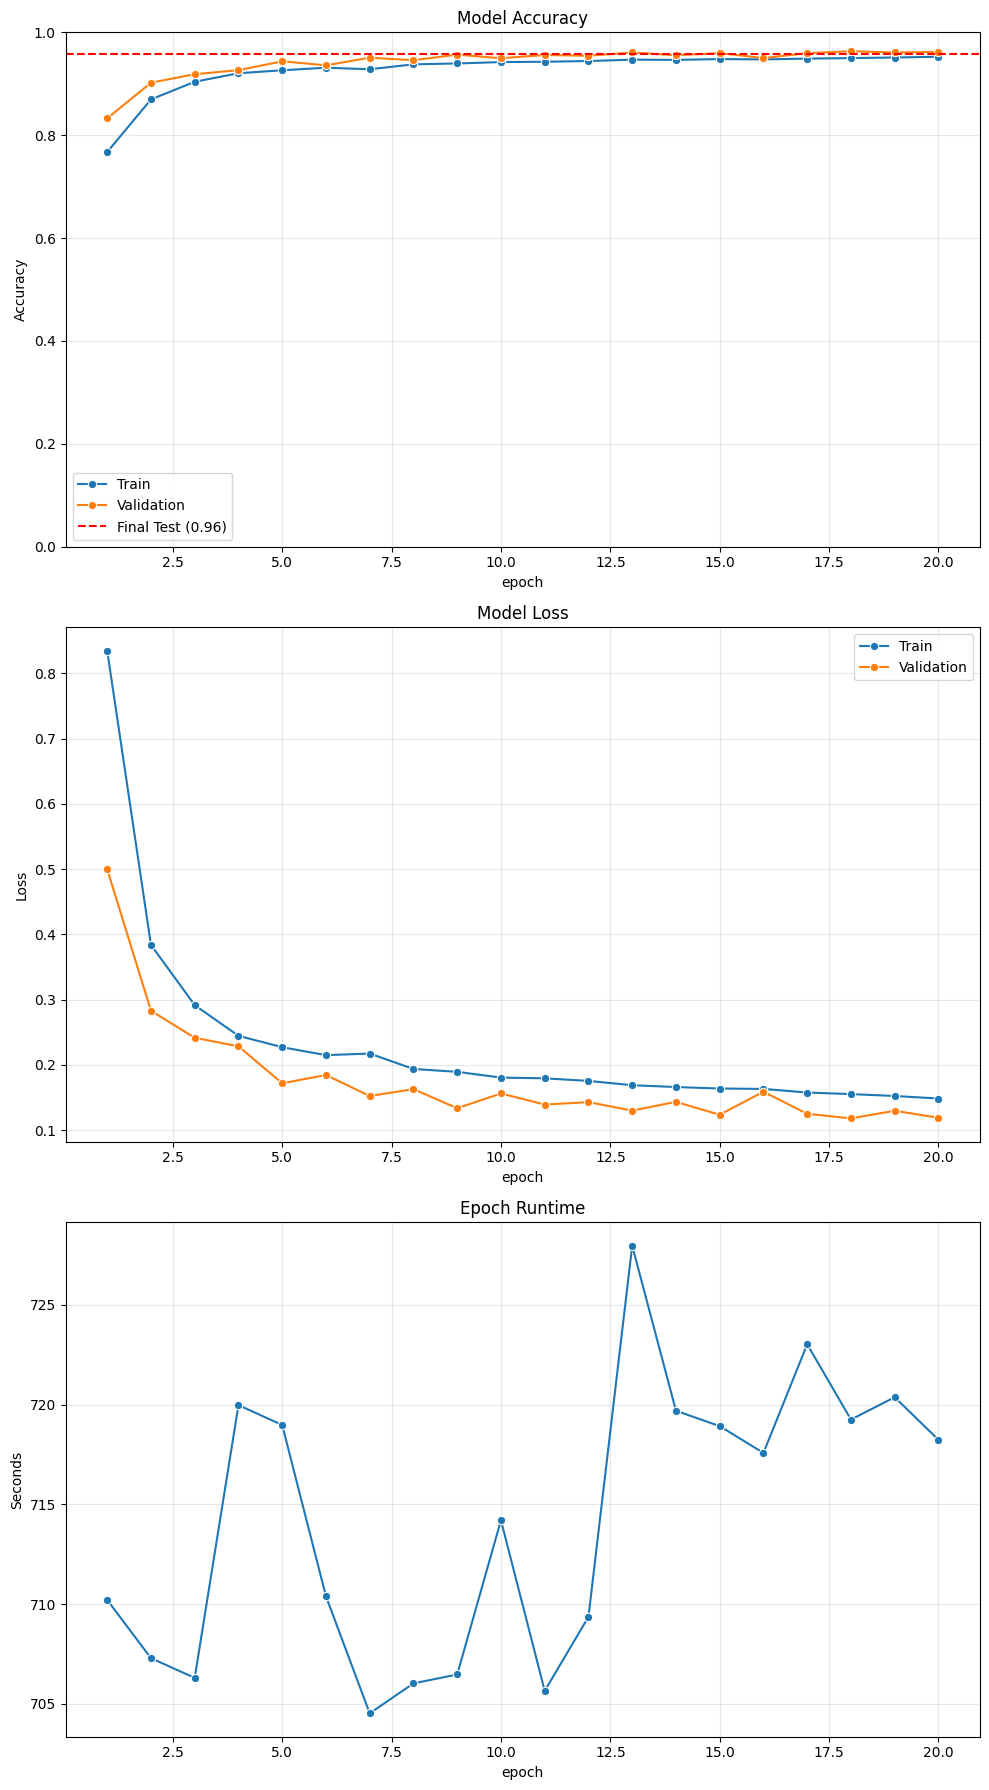

In [31]:
df = pd.DataFrame(cnn_results)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))


# Accuracy
sns.lineplot(x='epoch', y='Accuracy', data=df, ax=ax1, label='Train', marker='o')
sns.lineplot(x='epoch', y='test Accuracy', data=df, ax=ax1, label='Validation', marker='o')
ax1.axhline(y=final_test_acc, color='red', linestyle='--', label=f'Final Test ({final_test_acc:.2f})')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Loss
sns.lineplot(x='epoch', y='Train Loss', data=df, ax=ax2, label='Train', marker='o')
sns.lineplot(x='epoch', y='Test Loss', data=df, ax=ax2, label='Validation', marker='o')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Epoch time
sns.lineplot(x='epoch', y='Epoch Time (sec)', data=df, ax=ax3, marker='o')
ax3.set_title('Epoch Runtime')
ax3.set_ylabel('Seconds')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# ReNet model
C = 1
classes = 4

# Load pretrained ResNet18
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify first conv layer for 1-channel (grayscale) input
model_resnet.conv1 = nn.Conv2d(
    in_channels=C,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Replace final classification layer for 4 classes
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, classes)

# Move model to device
model_resnet = model_resnet.to(device)

print("ResNet model on:", next(model_resnet.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/port/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████████████████████████████████| 44.7M/44.7M [00:02<00:00, 22.4MB/s]


ResNet model on: mps:0


In [15]:
# Train ResNet
resnet_results = train_simple_network(
    model_resnet,
    loss_func,
    train_loader,
    test_loader=val_loader,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    epochs=20
)

model_resnet.eval()
test_preds_resnet, test_labels_resnet = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_resnet(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds_resnet.extend(preds.cpu().numpy())
        test_labels_resnet.extend(labels.cpu().numpy())

final_test_acc_resnet = accuracy_score(test_labels_resnet, test_preds_resnet)
print(f"\n[FINAL Test Accuracy: {final_test_acc_resnet:.4f}")

Epoch 1/20:, Train Acc: 0.8951, Test Acc: 0.9260, Test Loss: 0.2338 Time: 680.2s
Epoch 2/20:, Train Acc: 0.9286, Test Acc: 0.9443, Test Loss: 0.1707 Time: 674.7s
Epoch 3/20:, Train Acc: 0.9356, Test Acc: 0.9288, Test Loss: 0.2252 Time: 673.1s
Epoch 4/20:, Train Acc: 0.9410, Test Acc: 0.9519, Test Loss: 0.1624 Time: 676.1s
Epoch 5/20:, Train Acc: 0.9433, Test Acc: 0.9482, Test Loss: 0.1655 Time: 676.6s
Epoch 6/20:, Train Acc: 0.9471, Test Acc: 0.9550, Test Loss: 0.1408 Time: 673.9s
Epoch 7/20:, Train Acc: 0.9486, Test Acc: 0.9579, Test Loss: 0.1346 Time: 674.5s
Epoch 8/20:, Train Acc: 0.9515, Test Acc: 0.9570, Test Loss: 0.1321 Time: 671.9s
Epoch 9/20:, Train Acc: 0.9528, Test Acc: 0.9519, Test Loss: 0.1659 Time: 673.7s
Epoch 10/20:, Train Acc: 0.9545, Test Acc: 0.9621, Test Loss: 0.1168 Time: 675.9s
Epoch 11/20:, Train Acc: 0.9548, Test Acc: 0.9638, Test Loss: 0.1116 Time: 674.7s
Epoch 12/20:, Train Acc: 0.9567, Test Acc: 0.9640, Test Loss: 0.1115 Time: 674.9s
Epoch 13/20:, Train Acc: 

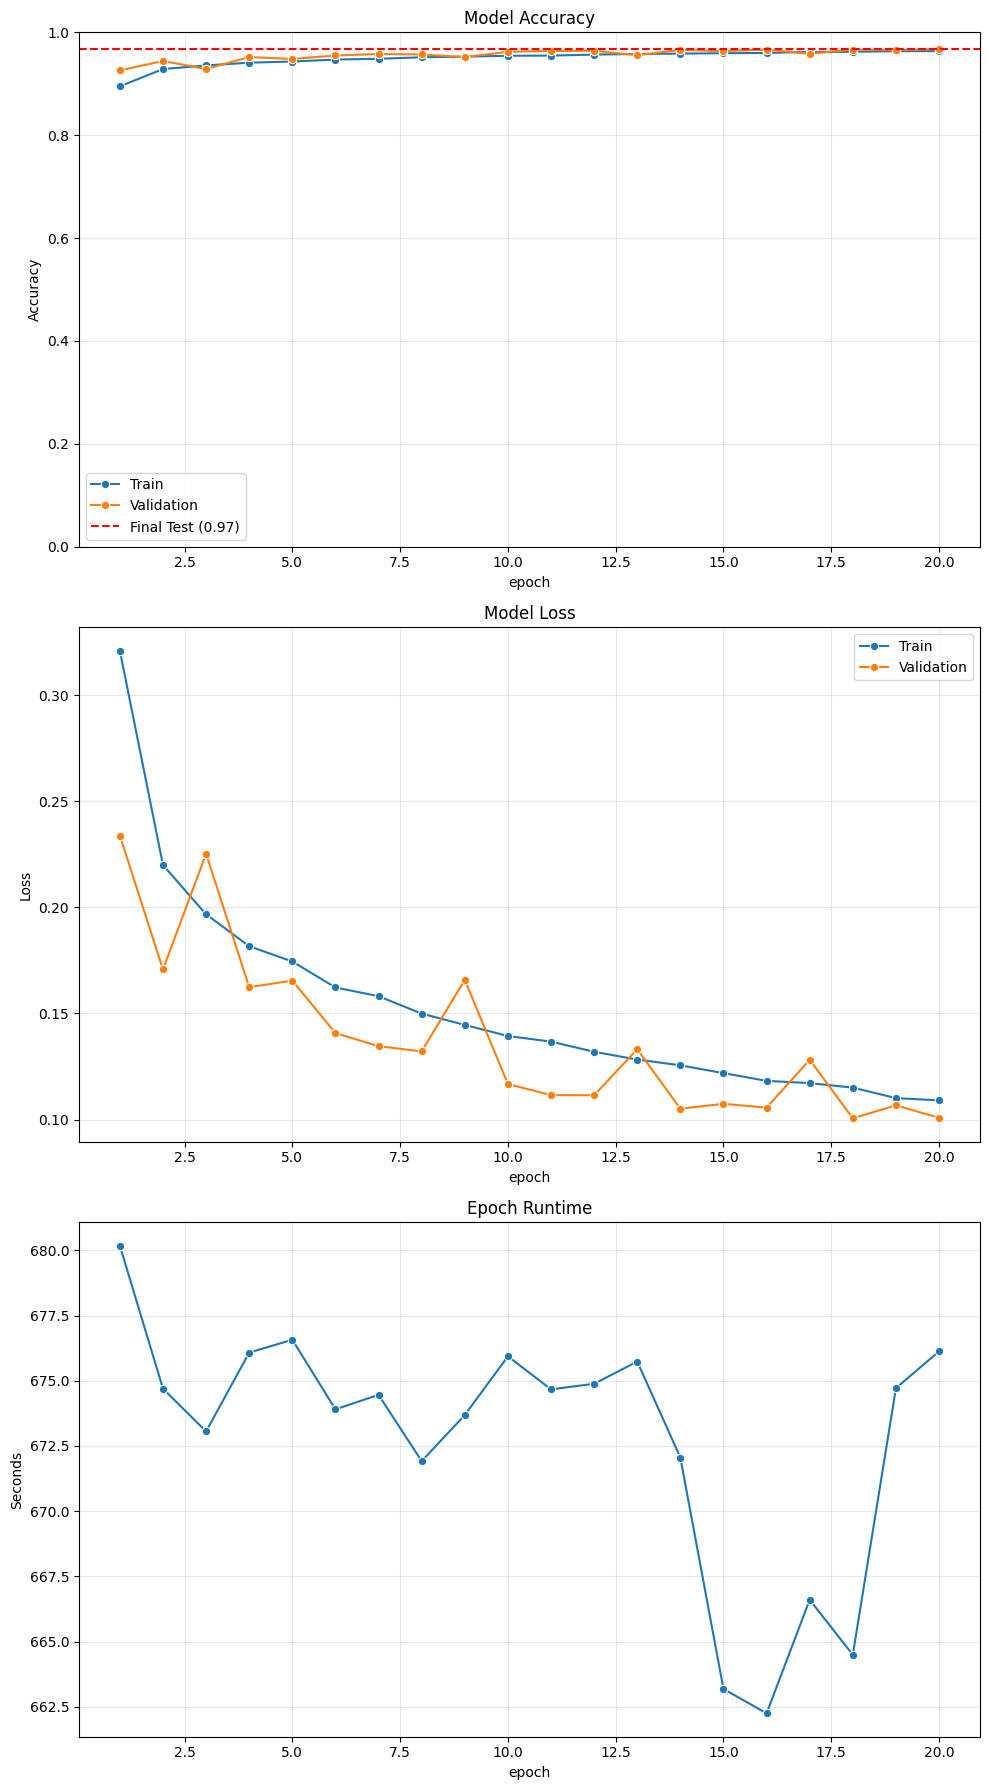

In [32]:
df = pd.DataFrame(resnet_results)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# Accuracy
sns.lineplot(x='epoch', y='Accuracy', data=df, ax=ax1, label='Train', marker='o')
sns.lineplot(x='epoch', y='test Accuracy', data=df, ax=ax1, label='Validation', marker='o')
ax1.axhline(y=final_test_acc_resnet, color='red', linestyle='--', label=f'Final Test ({final_test_acc_resnet:.2f})')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Loss
sns.lineplot(x='epoch', y='Train Loss', data=df, ax=ax2, label='Train', marker='o')
sns.lineplot(x='epoch', y='Test Loss', data=df, ax=ax2, label='Validation', marker='o')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Epoch time
sns.lineplot(x='epoch', y='Epoch Time (sec)', data=df, ax=ax3, marker='o')
ax3.set_title('Epoch Runtime')
ax3.set_ylabel('Seconds')
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("resnet_training_results.png", dpi=300, bbox_inches="tight")

plt.show()

## Evaluations


 Scratch CNN Classification Report
              precision    recall  f1-score   support

         CNV       0.97      0.96      0.97      3746
         DME       0.93      0.93      0.93      1161
      DRUSEN       0.89      0.79      0.84       887
      NORMAL       0.96      0.99      0.98      5139

    accuracy                           0.96     10933
   macro avg       0.94      0.92      0.93     10933
weighted avg       0.96      0.96      0.96     10933

Plot saved as: Scratch_CNN_confusion_matrix.png


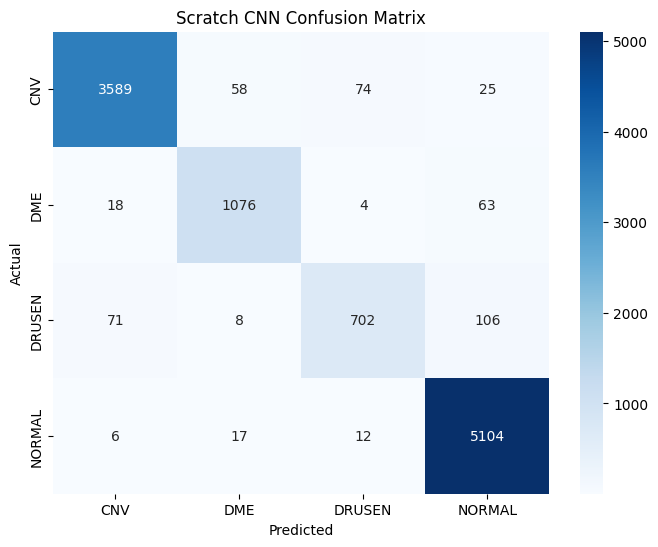


 ResNet18 Classification Report
              precision    recall  f1-score   support

         CNV       0.97      0.98      0.98      3746
         DME       0.96      0.94      0.95      1161
      DRUSEN       0.93      0.79      0.85       887
      NORMAL       0.97      0.99      0.98      5139

    accuracy                           0.97     10933
   macro avg       0.96      0.93      0.94     10933
weighted avg       0.97      0.97      0.97     10933

Plot saved as: ResNet18_confusion_matrix.png


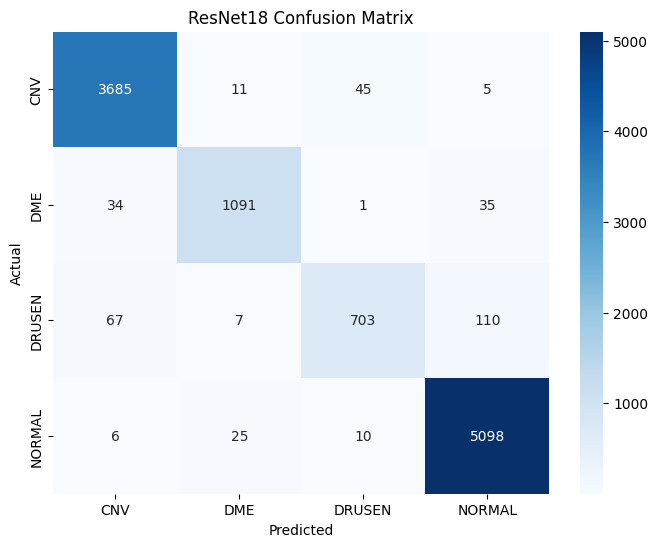

In [26]:
def plot_model_performance(y_true, y_pred, class_names, model_name="Model"):
    print(f'\n {model_name} Classification Report')
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    file_name = f"{model_name.replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Plot saved as: {file_name}")
    
    plt.show()

plot_model_performance(test_labels, test_preds, class_names, "Scratch CNN")
plot_model_performance(test_labels_resnet, test_preds_resnet, class_names, "ResNet18")